In [1]:
# Этот ноутбук подготовлен для ЛР3 (KWS).
# Запускайте ячейки сверху вниз.

# Лабораторная работа 3

**ФИО:** Алимбеков Рауль Азатович  
**Группа:** БВТ2201  
**Тема:** KWS (Keyword Spotting) для слов `one`…`nine` (цифры прописью) на Google Speech Commands

В ноутбуке выполнены шаги ЛР3: подготовка данных, baseline, серия экспериментов, анализ ошибок и выбор финальной модели.

In [2]:
# Если библиотек не хватает, раскомментируйте строку ниже:
# !pip install -q numpy pandas matplotlib scikit-learn librosa soundfile torchaudio

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import joblib

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

TARGET_LABELS = [
    "one",
    "two",
    "three",
    "four",
    "five",
    "six",
    "seven",
    "eight",
    "nine",
    "silence",
    "unknown",
]

DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup completed")

Setup completed


## Шаг 1. Подготовка данных

Используется официальный датасет `torchaudio.datasets.SPEECHCOMMANDS` с учётом speaker-disjoint split (`training`, `validation`, `testing`) из ЛР2.

Используем все доступные записи целевых классов (без ограничения по количеству).

In [3]:
import librosa
import torchaudio

# Шаг 1: загрузка официальных split'ов
train_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="training", download=True)
val_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="validation", download=True)
test_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="testing", download=True)

print(f"train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
print("Dataset init OK")

train=84843, val=9981, test=11005
Dataset init OK


In [4]:
m = train_ds.get_metadata(0)
m

('speech_commands_v0.02/backward/0165e0e8_nohash_0.wav',
 16000,
 'backward',
 '0165e0e8',
 0)

In [5]:
# Шаг 1.1: распределение классов в сырых split (без фильтрации)

def count_labels_raw(dataset):
    counts = {}
    for rel_path in dataset._walker:
        label = Path(rel_path).parent.name
        counts[label] = counts.get(label, 0) + 1
    return pd.Series(counts).sort_values(ascending=False)

raw_train_counts = count_labels_raw(train_ds)
raw_val_counts = count_labels_raw(val_ds)
raw_test_counts = count_labels_raw(test_ds)

print(f"Raw train classes: {len(raw_train_counts)}")
print(f"Raw val classes: {len(raw_val_counts)}")
print(f"Raw test classes: {len(raw_test_counts)}")

print("\nAll classes in raw train:")
display(raw_train_counts.to_frame("count"))

print("\nAll classes in raw val:")
display(raw_val_counts.to_frame("count"))

print("\nAll classes in raw test:")
display(raw_test_counts.to_frame("count"))

# Общая сводная таблица по всем split
raw_counts_all = pd.concat(
    [
        raw_train_counts.rename("train"),
        raw_val_counts.rename("val"),
        raw_test_counts.rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nAll classes across train/val/test:")
display(raw_counts_all.sort_values("train", ascending=False))

Raw train classes: 35
Raw val classes: 35
Raw test classes: 35

All classes in raw train:


,count
zero,3250
five,3240
yes,3228
seven,3205
nine,3170
one,3140
down,3134
no,3130
two,3111
stop,3111



All classes in raw val:


,count
no,406
yes,397
seven,387
zero,384
six,378
down,377
four,373
off,373
go,372
five,367



All classes in raw test:


,count
five,445
up,425
two,424
yes,419
zero,418
left,412
stop,411
eight,408
nine,408
down,406



All classes across train/val/test:


,train,val,test
zero,3250,384,418
five,3240,367,445
yes,3228,397,419
seven,3205,387,406
nine,3170,356,408
one,3140,351,399
down,3134,377,406
no,3130,406,405
two,3111,345,424
stop,3111,350,411


In [6]:
# Шаг 2: функция выборки целевых классов из split

def collect_subset_paths(dataset, labels):
    rows = []
    counters = {lbl: 0 for lbl in labels}

    archive = Path(dataset._archive)

    for rel_path in dataset._walker:
        path_obj = Path(rel_path)
        label = path_obj.parent.name
        if label not in labels:
            continue

        # У некоторых версий torchaudio в _walker уже почти полный путь,
        # у других — относительный. Берем первый реально существующий вариант.
        candidates = [
            path_obj,
            archive / path_obj,
            Path.cwd() / path_obj,
        ]
        resolved = next((p for p in candidates if p.exists()), None)
        if resolved is None:
            continue

        rows.append((str(resolved), label))
        counters[label] += 1

    return rows, counters

base_labels = [lbl for lbl in TARGET_LABELS if lbl not in ("silence", "unknown")]

train_rows_base, train_count_base = collect_subset_paths(train_ds, base_labels)
val_rows_base, val_count_base = collect_subset_paths(val_ds, base_labels)
test_rows_base, test_count_base = collect_subset_paths(test_ds, base_labels)

print("Base labels collected:")
print("train:", train_count_base)
print("val:", val_count_base)
print("test:", test_count_base)
print("Example base file:", train_rows_base[0] if train_rows_base else "not found")

Base labels collected:
train: {'one': 3140, 'two': 3111, 'three': 2966, 'four': 2955, 'five': 3240, 'six': 3088, 'seven': 3205, 'eight': 3033, 'nine': 3170}
val: {'one': 351, 'two': 345, 'three': 356, 'four': 373, 'five': 367, 'six': 378, 'seven': 387, 'eight': 346, 'nine': 356}
test: {'one': 399, 'two': 424, 'three': 405, 'four': 400, 'five': 445, 'six': 394, 'seven': 406, 'eight': 408, 'nine': 408}
Example base file: ('data/SpeechCommands/speech_commands_v0.02/eight/004ae714_nohash_0.wav', 'eight')


In [7]:
# Шаг 3.1: формируем класс unknown (стратифицированно по нецелевым словам)

def collect_unknown_paths(dataset, known_labels, unknown_count=None, seed=42):
    archive = Path(dataset._archive)
    rng = np.random.default_rng(seed)

    # Собираем неизвестные примеры по каждому классу отдельно
    per_label_rows = {}
    for rel_path in dataset._walker:
        path_obj = Path(rel_path)
        label = path_obj.parent.name

        # Исключаем целевые команды и служебные папки
        if label in known_labels or label == "_background_noise_":
            continue

        candidates = [path_obj, archive / path_obj, Path.cwd() / path_obj]
        resolved = next((p for p in candidates if p.exists()), None)
        if resolved is None:
            continue

        per_label_rows.setdefault(label, []).append((str(resolved), "unknown"))

    unknown_labels = sorted(per_label_rows.keys())
    if not unknown_labels:
        return [], 0

    # Если лимит не задан — берем все неизвестные записи
    if unknown_count is None:
        all_rows = []
        for lbl in unknown_labels:
            all_rows.extend(per_label_rows[lbl])
        return all_rows, len(unknown_labels)

    # Стратифицированная выборка: примерно поровну из каждого unknown-класса
    per_class = max(1, unknown_count // len(unknown_labels))
    remainder = unknown_count % len(unknown_labels)

    selected = []
    for i, lbl in enumerate(unknown_labels):
        pool = per_label_rows[lbl]
        take = per_class + (1 if i < remainder else 0)
        if len(pool) <= take:
            selected.extend(pool)
        else:
            idx = rng.choice(len(pool), size=take, replace=False)
            selected.extend([pool[j] for j in idx])

    # Если где-то классов было мало и не добрали общий лимит — добираем случайно из остатка
    if len(selected) < unknown_count:
        selected_set = set(selected)
        rest = []
        for lbl in unknown_labels:
            for row in per_label_rows[lbl]:
                if row not in selected_set:
                    rest.append(row)
        need = min(unknown_count - len(selected), len(rest))
        if need > 0:
            idx = rng.choice(len(rest), size=need, replace=False)
            selected.extend([rest[j] for j in idx])

    return selected, len(unknown_labels)

known_labels = base_labels  # те же 9 цифр, что в TARGET_LABELS (без silence/unknown)
train_unknown_count = max(train_count_base.values()) if train_count_base else 0
val_unknown_count = max(val_count_base.values()) if val_count_base else 0
test_unknown_count = max(test_count_base.values()) if test_count_base else 0

train_unknown, train_unknown_classes = collect_unknown_paths(train_ds, known_labels, train_unknown_count, seed=SEED + 10)
val_unknown, val_unknown_classes = collect_unknown_paths(val_ds, known_labels, val_unknown_count, seed=SEED + 11)
test_unknown, test_unknown_classes = collect_unknown_paths(test_ds, known_labels, test_unknown_count, seed=SEED + 12)

print("Unknown collected (stratified):")
print("train unknown:", len(train_unknown), "| unknown classes:", train_unknown_classes)
print("val unknown:", len(val_unknown), "| unknown classes:", val_unknown_classes)
print("test unknown:", len(test_unknown), "| unknown classes:", test_unknown_classes)
print("Approx per unknown class (train):", int(round(len(train_unknown) / max(train_unknown_classes, 1))))
print("Example unknown row:", train_unknown[0] if train_unknown else "not found")

Unknown collected (stratified):
train unknown: 3240 | unknown classes: 26
val unknown: 387 | unknown classes: 26
test unknown: 445 | unknown classes: 26
Approx per unknown class (train): 125
Example unknown row: ('data/SpeechCommands/speech_commands_v0.02/backward/1a994c9f_nohash_3.wav', 'unknown')


In [8]:
# Шаг 3: функция генерации класса silence

def make_silence_rows(dataset, count, seed=42):
    rng = np.random.default_rng(seed)

    archive = Path(dataset._archive)
    candidates = [
        archive / "_background_noise_",
        archive.parent / "speech_commands_v0.02" / "_background_noise_",
        DATA_DIR / "SpeechCommands" / "speech_commands_v0.02" / "_background_noise_",
    ]

    noise_files = []
    for c in candidates:
        files = sorted(c.glob("*.wav"))
        if files:
            noise_files = files
            break

    rows = []
    if noise_files:
        for _ in range(count):
            f = noise_files[rng.integers(0, len(noise_files))]
            y, sr = librosa.load(str(f), sr=None, mono=True)
            duration = len(y) / sr
            max_offset = max(0.0, duration - 1.0)
            offset = float(rng.uniform(0.0, max_offset)) if max_offset > 0 else 0.0
            rows.append((str(f), "silence", offset, 1.0))
    else:
        rows = [(None, "silence", 0.0, 1.0) for _ in range(count)]

    return rows

train_silence_count = max(train_count_base.values()) if train_count_base else 0
val_silence_count = max(val_count_base.values()) if val_count_base else 0
test_silence_count = max(test_count_base.values()) if test_count_base else 0

train_silence = make_silence_rows(train_ds, train_silence_count, seed=SEED)
val_silence = make_silence_rows(val_ds, val_silence_count, seed=SEED + 1)
test_silence = make_silence_rows(test_ds, test_silence_count, seed=SEED + 2)

print("Silence collected:")
print("train silence:", len(train_silence))
print("val silence:", len(val_silence))
print("test silence:", len(test_silence))
print("Example silence row:", train_silence[0] if train_silence else "not found")

Silence collected:
train silence: 3240
val silence: 387
test silence: 445
Example silence row: ('data/SpeechCommands/speech_commands_v0.02/_background_noise_/doing_the_dishes.wav', 'silence', 41.33494295097251, 1.0)


In [9]:
# Шаг 4: объединяем команды + silence + unknown
train_rows = train_rows_base + train_silence + train_unknown
val_rows = val_rows_base + val_silence + val_unknown
test_rows = test_rows_base + test_silence + test_unknown

train_count = dict(train_count_base)
val_count = dict(val_count_base)
test_count = dict(test_count_base)

train_count["silence"] = len(train_silence)
val_count["silence"] = len(val_silence)
test_count["silence"] = len(test_silence)

train_count["unknown"] = len(train_unknown)
val_count["unknown"] = len(val_unknown)
test_count["unknown"] = len(test_unknown)

print("Collected:")
print("train:", train_count)
print("val:", val_count)
print("test:", test_count)
print("Example final row:", train_rows[0] if train_rows else "not found")

Collected:
train: {'one': 3140, 'two': 3111, 'three': 2966, 'four': 2955, 'five': 3240, 'six': 3088, 'seven': 3205, 'eight': 3033, 'nine': 3170, 'silence': 3240, 'unknown': 3240}
val: {'one': 351, 'two': 345, 'three': 356, 'four': 373, 'five': 367, 'six': 378, 'seven': 387, 'eight': 346, 'nine': 356, 'silence': 387, 'unknown': 387}
test: {'one': 399, 'two': 424, 'three': 405, 'four': 400, 'five': 445, 'six': 394, 'seven': 406, 'eight': 408, 'nine': 408, 'silence': 445, 'unknown': 445}
Example final row: ('data/SpeechCommands/speech_commands_v0.02/eight/004ae714_nohash_0.wav', 'eight')


In [10]:
# Feature engineering: MFCC + статистики по времени
from tqdm.auto import tqdm


def extract_features(audio, sr=16000, n_mfcc=20):
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    if len(audio) < sr:
        audio = np.pad(audio, (0, sr - len(audio)))
    elif len(audio) > sr:
        audio = audio[:sr]

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)

    # mean + std дают компактное представление для классических моделей
    feats = np.concatenate([
        mfcc.mean(axis=1),
        mfcc.std(axis=1),
        delta.mean(axis=1),
        delta.std(axis=1),
    ])
    return feats


def build_xy(rows, cache_prefix=None):
    if cache_prefix:
        x_path = ARTIFACTS_DIR / f"{cache_prefix}_X.npy"
        y_path = ARTIFACTS_DIR / f"{cache_prefix}_y.npy"
        if x_path.exists() and y_path.exists():
            print(f"Loaded cache: {cache_prefix}")
            X_cached = np.load(x_path)
            y_cached = np.load(y_path, allow_pickle=True)
            if len(y_cached) == len(rows):
                return X_cached, y_cached
            print(
                f"Cache size mismatch for {cache_prefix}: "
                f"cache={len(y_cached)} vs rows={len(rows)}. Recomputing..."
            )

    def normalize_audio_path(audio_path):
        if audio_path is None:
            return None

        p = Path(audio_path)
        if p.exists():
            return str(p)

        # Чиним старый путь вида data/SpeechCommands/data/SpeechCommands/...
        marker = "speech_commands_v0.02/"
        s = str(audio_path).replace("\\", "/")
        if marker in s:
            tail = s.split(marker, 1)[1]
            fixed = DATA_DIR / "SpeechCommands" / "speech_commands_v0.02" / tail
            if fixed.exists():
                return str(fixed)

        return str(p)

    X, y = [], []
    for row in tqdm(rows, desc=f"Extract {cache_prefix or 'dataset'}"):
        # Обычный класс: (audio_path, label)
        # Класс silence: (audio_path, "silence", offset_sec, duration_sec)
        if len(row) == 2:
            audio_path, label = row
            audio_path = normalize_audio_path(audio_path)
            if audio_path is None or not Path(audio_path).exists():
                continue
            audio, sr = librosa.load(audio_path, sr=None, mono=True)
        else:
            audio_path, label, offset_sec, duration_sec = row
            if audio_path is None:
                # Фолбек для класса silence: чистый нулевой сигнал 1 сек
                sr = 16000
                audio = np.zeros(sr, dtype=np.float32)
            else:
                audio_path = normalize_audio_path(audio_path)
                if audio_path is None or not Path(audio_path).exists():
                    continue
                audio, sr = librosa.load(
                    audio_path,
                    sr=None,
                    mono=True,
                    offset=offset_sec,
                    duration=duration_sec,
                )

        X.append(extract_features(audio, sr))
        y.append(label)

    X = np.array(X)
    y = np.array(y)

    if cache_prefix:
        np.save(x_path, X)
        np.save(y_path, y)
        print(f"Saved cache: {cache_prefix}")

    return X, y


X_train, y_train = build_xy(train_rows, cache_prefix="train")
X_val, y_val = build_xy(val_rows, cache_prefix="val")
X_test, y_test = build_xy(test_rows, cache_prefix="test")

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Loaded cache: train
Loaded cache: val
Loaded cache: test
Shapes: (34388, 80) (4033, 80) (4579, 80)


## Шаг 2. Baseline-модель

Baseline для классификации: `LogisticRegression` на MFCC-признаках.

Основная метрика: **macro F1** (согласовано с ЛР1/ЛР2).

In [11]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

baseline.fit(X_train, y_train)
val_pred_baseline = baseline.predict(X_val)

baseline_f1 = f1_score(y_val, val_pred_baseline, average="macro")
print(f"Baseline macro F1 (val): {baseline_f1:.4f}")
print(classification_report(y_val, val_pred_baseline, digits=4))

Baseline macro F1 (val): 0.6577
              precision    recall  f1-score   support

       eight     0.7086    0.7168    0.7126       346
        five     0.5858    0.5858    0.5858       367
        four     0.7577    0.7292    0.7432       373
        nine     0.5504    0.7051    0.6182       356
         one     0.5821    0.6467    0.6127       351
       seven     0.6442    0.6925    0.6675       387
     silence     0.9393    1.0000    0.9687       387
         six     0.7661    0.7884    0.7771       378
       three     0.6805    0.6461    0.6628       356
         two     0.6987    0.6116    0.6522       345
     unknown     0.2953    0.1938    0.2340       387

    accuracy                         0.6650      4033
   macro avg     0.6553    0.6651    0.6577      4033
weighted avg     0.6553    0.6650    0.6577      4033



## Шаг 3-4. Экспериментальный пайплайн и серия экспериментов

Логируем эксперименты в таблицу `pandas`: модель, гиперпараметры, macro F1 на валидации.

Пробуем:
1. Улучшенную логистическую регрессию (поиск `C`)
2. RandomForest (поиск глубины/числа деревьев)

In [12]:
experiments = []

def log_experiment(name, model, X_tr, y_tr, X_va, y_va, params=None):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    score = f1_score(y_va, pred, average="macro")
    experiments.append({
        "name": name,
        "params": str(params) if params else "{}",
        "val_macro_f1": score,
    })
    return model, score, pred

# Exp 1: Logistic Regression + GridSearch
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1200, random_state=SEED)),
])

lr_grid = GridSearchCV(
    lr_pipe,
    param_grid={"clf__C": [0.5, 1.0, 2.0, 5.0]},
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
)

lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_
_, lr_f1, lr_pred = log_experiment(
    "LogReg_tuned", lr_best, X_train, y_train, X_val, y_val, lr_grid.best_params_
)

# Exp 2: RandomForest + GridSearch
rf = RandomForestClassifier(random_state=SEED)
rf_grid = GridSearchCV(
    rf,
    param_grid={
        "n_estimators": [150, 250],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
    },
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
_, rf_f1, rf_pred = log_experiment(
    "RandomForest_tuned", rf_best, X_train, y_train, X_val, y_val, rf_grid.best_params_
)

exp_df = pd.DataFrame(experiments).sort_values("val_macro_f1", ascending=False)
exp_df

,name,params,val_macro_f1
0,LogReg_tuned,{'clf__C': 0.5},0.657586
1,RandomForest_tuned,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.621996


## Шаг 5. Анализ ошибок

Для лучшей модели строим confusion matrix и смотрим примеры ошибок.

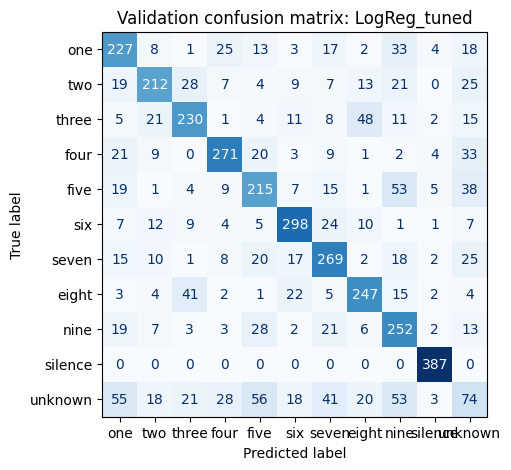

Количество ошибок на validation: 1351


,true,pred
0,eight,six
1,eight,three
2,eight,three
3,eight,three
4,eight,three
5,eight,silence
6,eight,three
7,eight,unknown
8,eight,two
9,eight,three


In [13]:
best_name = exp_df.iloc[0]["name"]
if best_name == "RandomForest_tuned":
    best_model = rf_best
else:
    best_model = lr_best

val_pred_best = best_model.predict(X_val)
cm = confusion_matrix(y_val, val_pred_best, labels=TARGET_LABELS)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_LABELS)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Validation confusion matrix: {best_name}")
plt.show()

errors_idx = np.where(val_pred_best != y_val)[0]
print(f"Количество ошибок на validation: {len(errors_idx)}")

if len(errors_idx) > 0:
    sample_n = min(10, len(errors_idx))
    sample = errors_idx[:sample_n]
    err_df = pd.DataFrame({
        "true": y_val[sample],
        "pred": val_pred_best[sample],
    })
    display(err_df)
else:
    print("Ошибок на validation не найдено")

## Шаг 6. Финальная модель

Выбираем модель с лучшим `val_macro_f1`, переобучаем на `train + val`, оцениваем на `test` и сохраняем артефакт для инференса.

In [14]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

best_model.fit(X_trainval, y_trainval)
test_pred = best_model.predict(X_test)

test_f1 = f1_score(y_test, test_pred, average="macro")
print(f"Final model: {best_name}")
print(f"Macro F1 (test): {test_f1:.4f}")
print(classification_report(y_test, test_pred, digits=4))

model_path = ARTIFACTS_DIR / "kws_final_model.joblib"
joblib.dump({
    "model": best_model,
    "labels": TARGET_LABELS,
    "feature": "mfcc+delta(mean,std)",
    "sample_rate": 16000,
}, model_path)

print(f"Saved: {model_path}")

Final model: LogReg_tuned
Macro F1 (test): 0.6431
              precision    recall  f1-score   support

       eight     0.6699    0.6863    0.6780       408
        five     0.6158    0.5618    0.5875       445
        four     0.7197    0.7125    0.7161       400
        nine     0.5711    0.6789    0.6204       408
         one     0.5326    0.6140    0.5704       399
       seven     0.5911    0.7192    0.6489       406
     silence     0.9978    1.0000    0.9989       445
         six     0.8547    0.7614    0.8054       394
       three     0.5995    0.6099    0.6047       405
         two     0.5911    0.6274    0.6087       424
     unknown     0.3180    0.1865    0.2351       445

    accuracy                         0.6486      4579
   macro avg     0.6419    0.6507    0.6431      4579
weighted avg     0.6413    0.6486    0.6416      4579

Saved: artifacts/kws_final_model.joblib


## Вывод

- Реализован baseline и улучшенные модели для KWS (слова `one`…`nine` + `silence` + `unknown`).
- Проведены эксперименты с логированием метрик.
- Выполнен анализ ошибок через confusion matrix и примеры misclassification.
- Выбрана финальная модель и сохранена в `artifacts/kws_final_model.joblib`.

### Компромиссы
- `LogReg`: быстрее и легче для edge/near-edge сценария.
- `RandomForest`: потенциально выше качество, но тяжелее по памяти и медленнее.

Для строгой оценки latency/размера модели можно дополнительно измерить время инференса и размер артефакта в отдельной ячейке.

## Дополнительный эксперимент: Log-Mel + CNN (PyTorch)

В этом эксперименте используем 2D log-mel спектрограммы и небольшую CNN.

Примечания:
- чтобы запустить быстрее, можно ограничить число примеров на класс (`CNN_MAX_PER_CLASS`);
- для финального сравнения можно снять ограничение (`None`) и увеличить число эпох.

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CNN_EPOCHS = 10
CNN_BATCH_SIZE = 64
CNN_LR = 1e-3
CNN_MAX_PER_CLASS = None  # None -> использовать все доступные записи в split

print("Device:", DEVICE)

Device: cuda


### Log-Mel и данные для CNN

По шагам: ограничение числа примеров на класс -> загрузка аудио из строки таблицы -> log-mel признак -> класс `Dataset` -> сборка сплитов и `DataLoader`.

Обучение выполняется **на чистых записях**, без аугментаций (без waveform-augment и SpecAugment).


In [16]:
# Одна строка датасета → сырой аудиосигнал

def row_to_audio(row):
    if len(row) == 2:
        audio_path, _ = row
        audio_path = Path(audio_path)
        y, sr = librosa.load(str(audio_path), sr=None, mono=True)
        return y, sr

    audio_path, _, offset_sec, duration_sec = row
    if audio_path is None:
        return np.zeros(16000, dtype=np.float32), 16000

    y, sr = librosa.load(str(audio_path), sr=None, mono=True, offset=offset_sec, duration=duration_sec)
    return y, sr


In [17]:
# Log-mel спектрограмма (фиксированная длина 1 с при 16 kHz)

def extract_logmel(audio, sr=16000, n_mels=64, n_fft=512, hop_length=160):
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    if len(audio) < sr:
        audio = np.pad(audio, (0, sr - len(audio)))
    elif len(audio) > sr:
        audio = audio[:sr]

    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    # Нормализация на примере
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)
    return logmel.astype(np.float32)


In [18]:
class LogMelDataset(Dataset):
    def __init__(self, rows, label_to_idx):
        self.rows = rows
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        y, sr = row_to_audio(row)
        x = extract_logmel(y, sr)
        x = torch.from_numpy(x).unsqueeze(0)  # [1, n_mels, time]
        label = row[1]
        t = torch.tensor(self.label_to_idx[label], dtype=torch.long)
        return x, t


In [19]:
class CachedLogMelDataset(Dataset):
    def __init__(self, rows, label_to_idx, desc="Caching features"):
        self.label_to_idx = label_to_idx
        self.features = []
        self.targets = []
        
        print(f"{desc}...")
        for row in tqdm(rows, desc=desc, leave=False):
            y, sr = row_to_audio(row)
            x = extract_logmel(y, sr)
            # Сохраняем как float16 для экономии места в RAM, если нужно
            self.features.append(x)
            self.targets.append(self.label_to_idx[row[1]])
            
        self.features = np.array(self.features)
        self.targets = np.array(self.targets)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.features[idx]).unsqueeze(0)
        t = torch.tensor(self.targets[idx], dtype=torch.long)
        return x, t

In [20]:
# Сплиты, метки и DataLoader

train_rows_cnn = train_rows
val_rows_cnn = val_rows
test_rows_cnn = test_rows

labels_cnn = sorted(list(set([r[1] for r in train_rows_cnn + val_rows_cnn + test_rows_cnn])))
label_to_idx = {l: i for i, l in enumerate(labels_cnn)}
idx_to_label = {i: l for l, i in label_to_idx.items()}

train_ds_cnn = CachedLogMelDataset(train_rows, label_to_idx, desc="Caching Train")
val_ds_cnn = CachedLogMelDataset(val_rows, label_to_idx, desc="Caching Val")
test_ds_cnn = CachedLogMelDataset(test_rows, label_to_idx, desc="Caching Test")

_nw = 2

train_loader = DataLoader(train_ds_cnn, batch_size=CNN_BATCH_SIZE, shuffle=True, num_workers=_nw, pin_memory=True)
val_loader = DataLoader(val_ds_cnn, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=True)
test_loader = DataLoader(test_ds_cnn, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=True)

print("CNN labels:", labels_cnn)
print("Rows train/val/test:", len(train_rows_cnn), len(val_rows_cnn), len(test_rows_cnn))
print("CNN clean training (no augment) | num_workers:", _nw)


Caching Train...


Caching Val...


Caching Test...


CNN labels: ['eight', 'five', 'four', 'nine', 'one', 'seven', 'silence', 'six', 'three', 'two', 'unknown']
Rows train/val/test: 34388 4033 4579
CNN clean training (no augment) | num_workers: 2


Epoch 01/10 | 4.4s | lr=1e-03
  train  loss=1.6585  acc=0.4643  F1_macro=0.4325  F1_w=0.4340
  val    loss=1.4393  acc=0.4952  F1_macro=0.4748  F1_w=0.4753  <-- best val macro-F1
  best val F1_macro=0.4748 (epoch 1)


Epoch 02/10 | 3.7s | lr=1e-03
  train  loss=1.1312  acc=0.6659  F1_macro=0.6504  F1_w=0.6501
  val    loss=1.2036  acc=0.5961  F1_macro=0.5595  F1_w=0.5564  <-- best val macro-F1
  best val F1_macro=0.5595 (epoch 2)


Epoch 03/10 | 3.7s | lr=1e-03
  train  loss=0.8842  acc=0.7355  F1_macro=0.7255  F1_w=0.7248
  val    loss=1.0256  acc=0.6474  F1_macro=0.6262  F1_w=0.6285  <-- best val macro-F1
  best val F1_macro=0.6262 (epoch 3)


Epoch 04/10 | 3.6s | lr=1e-03
  train  loss=0.7564  acc=0.7692  F1_macro=0.7621  F1_w=0.7611
  val    loss=1.3322  acc=0.5810  F1_macro=0.5613  F1_w=0.5563
  best val F1_macro=0.6262 (epoch 3)


Epoch 05/10 | 3.6s | lr=1e-03
  train  loss=0.6731  acc=0.7934  F1_macro=0.7884  F1_w=0.7873
  val    loss=0.7695  acc=0.7545  F1_macro=0.7528  F1_w=0.7517  <-- best val macro-F1
  best val F1_macro=0.7528 (epoch 5)


...

Epoch 08/10 | 5.1s | lr=1e-03
  train  loss=0.5238  acc=0.8399  F1_macro=0.8374  F1_w=0.8366
  val    loss=0.7745  acc=0.7429  F1_macro=0.7369  F1_w=0.7357
  best val F1_macro=0.7801 (epoch 6)


Epoch 09/10 | 28.7s | lr=1e-03
  train  loss=0.4968  acc=0.8467  F1_macro=0.8445  F1_w=0.8437
  val    loss=0.6691  acc=0.7897  F1_macro=0.7772  F1_w=0.7757
  best val F1_macro=0.7801 (epoch 6)


Epoch 10/10 | 32.4s | lr=1e-03
  train  loss=0.4655  acc=0.8548  F1_macro=0.8528  F1_w=0.8521
  val    loss=0.8010  acc=0.7354  F1_macro=0.7260  F1_w=0.7241
  best val F1_macro=0.7801 (epoch 6)



CNN classification report (val):
              precision    recall  f1-score   support

       eight     0.9020    0.7977    0.8466       346
        five     0.9673    0.4033    0.5692       367
        four     0.7447    0.8525    0.7950       373
        nine     0.7462    0.8174    0.7802       356
         one     0.8595    0.9060    0.8821       351
       seven     0.8069    0.9070    0.8540       387
     silence     0.9821    0.9948    0.9884       387
         six     0.9101    0.8571    0.8828       378
       three     0.6438    0.9242    0.7589       356
         two     0.7317    0.9565    0.8291       345
     unknown     0.5124    0.3204    0.3943       387

    accuracy                         0.7920      4033
   macro avg     0.8006    0.7943    0.7801      4033
weighted avg     0.8005    0.7920    0.7789      4033



CNN macro F1 (test): 0.7643
              precision    recall  f1-score   support

       eight     0.9212    0.7451    0.8238       408
        five     0.9157    0.3663    0.5233       445
        four     0.7198    0.8350    0.7731       400
        nine     0.7061    0.7892    0.7454       408
         one     0.8364    0.8972    0.8658       399
       seven     0.7635    0.9064    0.8288       406
     silence     0.9978    0.9978    0.9978       445
         six     0.9272    0.8731    0.8993       394
       three     0.6267    0.9160    0.7442       405
         two     0.7242    0.9599    0.8256       424
     unknown     0.5018    0.3056    0.3799       445

    accuracy                         0.7755      4579
   macro avg     0.7855    0.7811    0.7643      4579
weighted avg     0.7855    0.7755    0.7607      4579



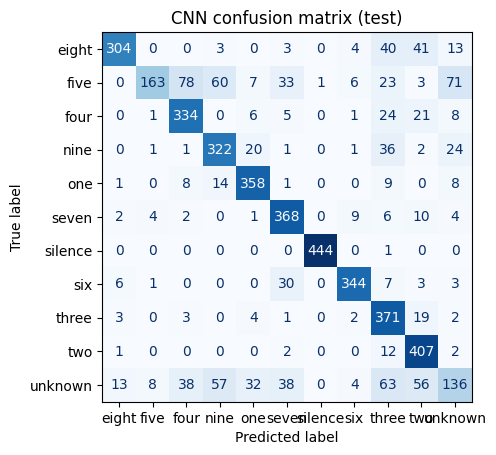

In [21]:
import time

from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

# Единая реализация CNN для всего проекта
from models.small_kws_cnn import SmallKwsCNN


def run_epoch(model, loader, optimizer=None, desc=""):
    is_train = optimizer is not None
    model.train(is_train)

    all_true, all_pred = [], []
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    it = loader
    if desc:
        it = tqdm(loader, desc=desc, leave=False)

    for xb, yb in it:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = loss_fn(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        pred = torch.argmax(logits, dim=1)
        all_true.extend(yb.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())

    n = max(len(loader.dataset), 1)
    avg_loss = total_loss / n
    acc = float(accuracy_score(all_true, all_pred))
    f1_macro = float(f1_score(all_true, all_pred, average="macro"))
    f1_weighted = float(f1_score(all_true, all_pred, average="weighted"))
    return avg_loss, acc, f1_macro, f1_weighted, all_true, all_pred


cnn_model = SmallKwsCNN(num_classes=len(labels_cnn)).to(DEVICE)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR)

best_state = None
best_val_f1 = -1.0
best_epoch = 0

for epoch in range(1, CNN_EPOCHS + 1):
    t0 = time.perf_counter()
    tr_loss, tr_acc, tr_f1m, tr_f1w, _, _ = run_epoch(
        cnn_model,
        train_loader,
        optimizer,
        desc=f"train {epoch}/{CNN_EPOCHS}",
    )
    va_loss, va_acc, va_f1m, va_f1w, va_true, va_pred = run_epoch(
        cnn_model,
        val_loader,
        optimizer=None,
        desc=f"valid {epoch}/{CNN_EPOCHS}",
    )
    ep_sec = time.perf_counter() - t0

    improved = ""
    if va_f1m > best_val_f1:
        best_val_f1 = va_f1m
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}
        improved = "  <-- best val macro-F1"

    print(
        f"Epoch {epoch:02d}/{CNN_EPOCHS} | {ep_sec:.1f}s | lr={CNN_LR:.0e}\n"
        f"  train  loss={tr_loss:.4f}  acc={tr_acc:.4f}  F1_macro={tr_f1m:.4f}  F1_w={tr_f1w:.4f}\n"
        f"  val    loss={va_loss:.4f}  acc={va_acc:.4f}  F1_macro={va_f1m:.4f}  F1_w={va_f1w:.4f}"
        f"{improved}\n"
        f"  best val F1_macro={best_val_f1:.4f} (epoch {best_epoch})"
    )

if best_state is not None:
    cnn_model.load_state_dict(best_state)

# Валидируем лучшую модель
_, _, _, _, y_val_true_idx, y_val_pred_idx = run_epoch(
    cnn_model, val_loader, optimizer=None, desc="val (best weights)"
)
y_val_true_lbl = np.array([idx_to_label[i] for i in y_val_true_idx])
y_val_pred_lbl = np.array([idx_to_label[i] for i in y_val_pred_idx])

print("\nCNN classification report (val):")
print(classification_report(y_val_true_lbl, y_val_pred_lbl, labels=labels_cnn, digits=4))

# Тест
_, _, _, _, y_test_true_idx, y_test_pred_idx = run_epoch(
    cnn_model, test_loader, optimizer=None, desc="test"
)
y_test_true_lbl = np.array([idx_to_label[i] for i in y_test_true_idx])
y_test_pred_lbl = np.array([idx_to_label[i] for i in y_test_pred_idx])

test_f1_cnn = f1_score(y_test_true_lbl, y_test_pred_lbl, average="macro")
print(f"CNN macro F1 (test): {test_f1_cnn:.4f}")
print(classification_report(y_test_true_lbl, y_test_pred_lbl, labels=labels_cnn, digits=4))

cm_cnn = confusion_matrix(y_test_true_lbl, y_test_pred_lbl, labels=labels_cnn)
ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=labels_cnn).plot(cmap="Blues", colorbar=False)
plt.title("CNN confusion matrix (test)")
plt.show()

In [22]:
# Сохранить CNN для скрипта cnn_kws_live_demo.py
from pathlib import Path

ART = Path("artifacts")
ART.mkdir(parents=True, exist_ok=True)
out = ART / "kws_cnn.pt"
torch.save(
    {"state_dict": cnn_model.state_dict(), "labels": labels_cnn},
    out,
)
print("Saved:", out.resolve())


Saved: /home/raul/code/mtuci-piis/artifacts/kws_cnn.pt
